<a href="https://colab.research.google.com/github/DarkLauroDFreitas/Calculo_N-merico_1_Miguel/blob/main/CN_atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade prática II
## Estabilidade e overflow em difusão 1D (Couette não estacionário)

**Objetivo:** investigar a relação entre estabilidade numérica, passo de tempo (Δt) e overflow em uma simulação simplificada de difusão de quantidade de movimento entre duas placas paralelas (escoamento de Couette em regime transiente).

Este notebook segue as 7 atividades propostas no roteiro.

## 0. Importações e função de simulação

Função fornecida no roteiro: integra a equação de difusão com Euler explícito no tempo e diferenças finitas centrais no espaço, e interrompe a execução ao detectar `overflow`/`invalid` (NaN).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(f"dt={dt}, {tipo.__name__}: falha no passo {passo}, "
                      f"t={passo * dt:.4f} s - {erro}")
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {"y": y, "u": u, "tempos": tempos, "maximos": maximos,
            "r": float(r), "falha": falha}

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


## 1. Verificação da estabilidade (Caso A e Caso B)

Malha com 21 pontos: Δy = H/(21-1). Limite: Δt_max = Δy²/(2ν).

In [ ]:
H = 0.01
nu = 1e-4
pontos = 21

dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)
print(f"dy = {dy} m")
print(f"dt_max = {dt_max} s")

for nome, dt in [("Caso A", 0.001), ("Caso B", 0.002)]:
    r = nu * dt / dy**2
    classificacao = "ESTAVEL (r <= 0.5)" if r <= 0.5 else "INSTAVEL (r > 0.5)"
    print(f"{nome}: dt={dt} s -> r={r:.2f} -> {classificacao}")

dy = 0.0005 m
dt_max = 0.0012499999999999998 s
Caso A: dt=0.001 s -> r=0.40 -> ESTAVEL (r <= 0.5)
Caso B: dt=0.002 s -> r=0.80 -> INSTAVEL (r > 0.5)


**Resultado:** Δy = 0,0005 m e Δt_max = 0,00125 s.

- **Caso A** (Δt = 0,001 s): r = 0,40 → **estável** (r ≤ 1/2, Δt < Δt_max).
- **Caso B** (Δt = 0,002 s): r = 0,80 → **instável** (r > 1/2, Δt > Δt_max).

Isso já permite prever, antes de rodar qualquer coisa, que o Caso B vai gerar oscilações crescentes.

## 2. Detecção de overflow — os 4 testes

In [ ]:
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo, passos=2000, pontos=21)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [ ]:
linhas = []
for nome, res in resultados.items():
    tipo, dt_str = nome.split(", dt=")
    linhas.append({
        "tipo numerico": tipo,
        "dt (s)": float(dt_str),
        "r": round(res["r"], 3),
        "overflow": res["falha"] is not None,
        "passo da falha": res["falha"] if res["falha"] is not None else "-",
    })

tabela = pd.DataFrame(linhas)
tabela

,tipo numerico,dt (s),r,overflow,passo da falha
0,float32,0.001,0.4,False,-
1,float32,0.002,0.8,True,121
2,float64,0.001,0.4,False,-
3,float64,0.002,0.8,True,917


/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


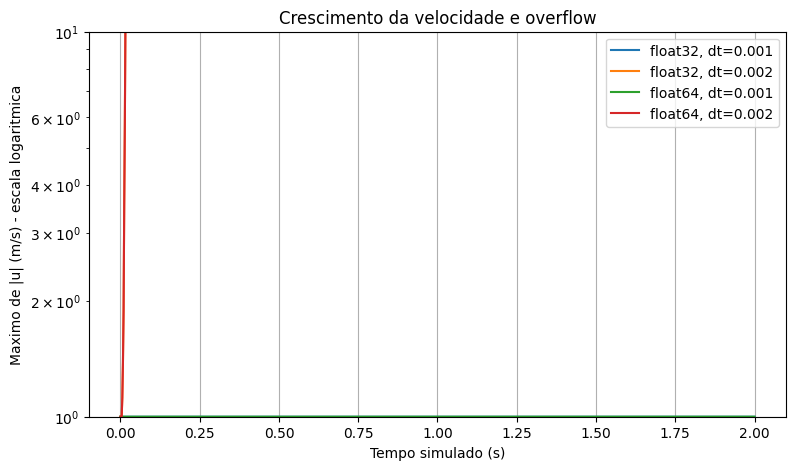

In [ ]:
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(resultado["tempos"], resultado["maximos"], label=nome)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

## 3. Interpretação física

No gráfico, as curvas com **r = 0,40** (Casos A, float32 e float64) permanecem estáveis: o máximo de |u| fica em 1 m/s durante toda a simulação, que é exatamente o valor imposto pela placa móvel — fisicamente consistente, já que a velocidade não pode superar U = 1 m/s em um escoamento de Couette sem forçantes externas.

As curvas com **r = 0,80** (Caso B) crescem de forma explosiva e aproximadamente exponencial a cada passo, até estourar a capacidade do tipo numérico. Isso não representa nenhum fenômeno físico: nenhuma equação de conservação de quantidade de movimento admite velocidades muito acima da velocidade da placa que está impondo o movimento. O crescimento é um artefato puramente numérico.

A causa está na fórmula reorganizada do esquema:

u_i^{n+1} = r·u_{i-1}^n + (1-2r)·u_i^n + r·u_{i+1}^n

Quando r > 1/2, o coeficiente (1-2r) fica negativo. A atualização deixa de ser uma média ponderada (coeficientes não negativos somando 1) e passa a amplificar qualquer diferença entre pontos vizinhos a cada passo — uma oscilação numérica que dobra (ou mais) de amplitude a cada iteração, até ultrapassar o maior valor representável do tipo de ponto flutuante (overflow).

## 4. Capacidade de representação: float32 vs float64

A mudança de tipo numérico **não elimina a instabilidade** — ela apenas atrasa a falha. Nos testes acima, com r = 0,80:

- `float32` estourou por volta do passo **121** (maior valor representável ≈ 3,4×10³⁸);
- `float64` só estourou por volta do passo **917** (maior valor representável ≈ 1,8×10³⁰⁸).

Como o erro cresce de forma aproximadamente geométrica a cada passo (fator ligado a |1-2r| > 1), o número de passos necessário para atingir o teto de representação é proporcional ao logaritmo desse teto. Como float64 tem uma faixa dinâmica muito maior (expoente de 11 bits contra 8 bits do float32), o número de iterações até o overflow é bem maior — mas a solução já estava fisicamente incorreta (|u| >> 1 m/s) muito antes disso em ambos os casos. Trocar o tipo numérico troca apenas o sintoma (quando o programa trava), não a causa (r > 1/2).

## 5. Refinamento da malha (41 pontos)

In [ ]:
pontos_novo = 41
dy_novo = H / (pontos_novo - 1)
dt_max_novo = dy_novo**2 / (2 * nu)
print(f"Nova malha: dy = {dy_novo} m")
print(f"Novo limite: dt_max = {dt_max_novo} s")

r_101 = nu * 0.001 / dy_novo**2
print(f"\nMantendo dt = 0.001 s -> r = {r_101:.2f} (> 0.5 => instavel)")

res_instavel = simular(0.001, np.float64, passos=2000, pontos=pontos_novo)
print("falha no passo:", res_instavel["falha"])

Nova malha: dy = 0.00025 m
Novo limite: dt_max = 0.00031249999999999995 s

Mantendo dt = 0.001 s -> r = 1.60 (> 0.5 => instavel)
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
falha no passo: 426


Ao dobrar a resolução da malha (21 → 41 pontos), Δy cai pela metade (0,0005 → 0,00025 m). Como Δt_max ∝ Δy², o novo limite de estabilidade cai para **1/4** do valor anterior: 0,00125 s → 0,0003125 s.

Mantendo Δt = 0,001 s (que era estável na malha grosseira), agora r = 1,60 — muito acima de 1/2 — e a simulação volta a divergir e sofrer overflow. **Refinar a malha sem reduzir o passo de tempo compatívelmente quebra a estabilidade**, mesmo sem alterar nada na física do problema.

In [ ]:
dt_estavel = 0.00025  # abaixo de dt_max_novo = 0.0003125 s
r_estavel = nu * dt_estavel / dy_novo**2
print(f"dt = {dt_estavel} s -> r = {r_estavel:.2f}")

res_estavel = simular(dt_estavel, np.float64, passos=2000, pontos=pontos_novo)
print("falha:", res_estavel["falha"], "(None = sem overflow)")
print("velocidade maxima final:", res_estavel["maximos"][-1], "m/s")

dt = 0.00025 s -> r = 0.40
dt=0.00025, float64: 2000 passos sem overflow.
falha: None (None = sem overflow)
velocidade maxima final: 1.0 m/s


Escolhendo Δt = 0,00025 s (abaixo de Δt_max = 0,0003125 s), r volta a 0,40 e a simulação permanece estável, com |u|_max = 1 m/s durante toda a execução — confirmando que o problema era exclusivamente a violação da condição r ≤ 1/2 na malha refinada.

## 6. Perfil de velocidade estacionário

In [ ]:
U = 1.0
passos_longos = 6000  # t_final = 6 s

res_final = simular(0.001, np.float64, passos=passos_longos, pontos=21)
y = res_final["y"]
u_num = res_final["u"]
u_est = U * (1 - y / H)

erro_inf = np.max(np.abs(u_num - u_est))
print(f"t final simulado: {res_final['tempos'][-1]} s")
print(f"Tempo caracteristico de difusao H^2/nu: {H**2/nu} s")
print(f"E_inf = max|u_i - u_est(y_i)| = {erro_inf:.3e} m/s")

dt=0.001, float64: 6000 passos sem overflow.
t final simulado: 6.0 s
Tempo caracteristico de difusao H^2/nu: 1.0 s
E_inf = max|u_i - u_est(y_i)| = 3.442e-15 m/s


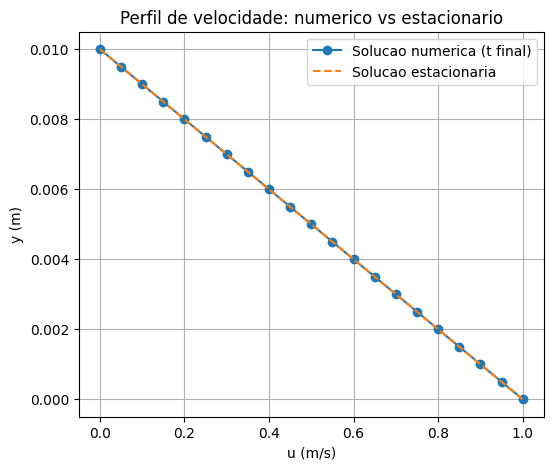

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(u_num, y, "o-", label="Solucao numerica (t final)")
plt.plot(u_est, y, "--", label="Solucao estacionaria")
plt.xlabel("u (m/s)")
plt.ylabel("y (m)")
plt.title("Perfil de velocidade: numerico vs estacionario")
plt.legend()
plt.grid(True)
plt.show()

O tempo característico de difusão do problema é H²/ν = 1 s. Simulando até t = 6 s (seis vezes esse tempo característico), a solução numérica já está indistinguível da solução estacionária esperada: E∞ é da ordem de 10⁻¹⁵ m/s, ou seja, no nível do erro de arredondamento de ponto flutuante, não um efeito físico.

Isso indica que 6 s de tempo simulado é mais do que suficiente para que o transiente se dissipe nesta configuração — mas se o tempo total simulado fosse muito menor (por exemplo, próximo de H²/ν ou abaixo dele), E∞ ainda incorporaria uma contribuição real do transiente ainda em curso, e não poderia ser atribuído só a erro numérico.

## 7. Conclusão

- **Refinar a malha** (Δy menor) sem ajustar o passo de tempo **reduz** o limite de estabilidade Δt_max, porque Δt_max ∝ Δy². Uma malha 2× mais fina exige um passo de tempo até 4× menor para permanecer estável.
- **Instabilidade numérica** e **overflow** são fenômenos distintos: a instabilidade (r > 1/2) faz o erro crescer geometricamente a cada passo desde a primeira iteração; o overflow é apenas o momento, muito depois, em que esse crescimento ultrapassa a faixa representável do tipo de ponto flutuante usado. A solução já estava fisicamente errada muito antes de haver overflow.
- **Trocar float32 por float64** apenas adia o overflow (mais faixa dinâmica), sem corrigir a causa raiz.
- **A correção real da falha** nesta simulação é sempre a mesma: garantir r = ν·Δt/Δy² ≤ 1/2, escolhendo Δt ≤ Δy²/(2ν) para a malha usada. Foi exatamente essa mudança — reduzir Δt para respeitar o novo Δt_max — que estabilizou tanto o Caso B (Δt = 0,002 s → precisaria de Δt ≤ 0,00125 s) quanto a malha refinada de 41 pontos (Δt = 0,001 s → precisou cair para Δt ≤ 0,0003125 s).